# 07MIAR - Redes Neuronales y Deep Learning: Proyecto de programación "*Deep Vision in classification tasks*"


# Datos del grupo

Grupo: GRUPOS PROYECTO PROGRAMACIÓN 6

Alumnos:

- David Jiménez Castro
- Michael Laudrup Luis González
- Pol Jorba Lloses
- Rodrigo Hernán Peralta


## Enunciado

En esta actividad, el alumno debe **evaluar y comparar dos estrategias** para la **clasificación de imágenes** empleando el **dataset asignado**. Los alumnos deberá resolver el reto proponiendo una solución válida **basada en aprendizaje profundo**, más concretamente en redes neuronales convolucionales (**CNNs**). Será indispensable que la solución propuesta siga el **pipeline visto en clase** para resolver este tipo de tareas de inteligencia artificial:

1.   **Carga** del conjunto de datos
2.   **Inspección** del conjunto de datos
3.   **Acondicionamiento** del conjunto de datos
4.   Desarrollo de la **arquitectura** de red neuronal y **entrenamiento** de la solución
5.   **Monitorización** del proceso de **entrenamiento** para la toma de decisiones
6.   **Evaluación** del modelo predictivo y planteamiento de la siguiente prueba experimental

### Estrategia 1: Entrenar desde cero o *from scratch*

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

### Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

## Normas a seguir

- Será **indispensable** realizar el **trabajo por parejas**. Dichas parejas de alumnxs se generarán **de manera automática** teniendo en cuenta el pais de residencia con el objetivo de facilitar el trabajo en equipo.  
- Se debe entregar un **ÚNICO FICHERO PDF POR ALUMNO** que incluya las instrucciones presentes en el Colab Noteboook y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso llevado a cabo en cada estrategia (i.e. carga de datos, inspección de datos, acondicionamiento, proceso de entrenamiento y proceso de validación del modelo).
- **La memoria del trabajo** (el fichero PDF mencionado en el punto anterior) deberá **subirla cada integrante del grupo** (aunque se trate de un documento idéntico) a la actividad que se habilitará **en CampusVIU**.
- Se recomienda trabajar respecto a un directorio base (**BASE_FOLDER**) para facilitar el trabajo en equipo. En este notebook se incluye un ejemplo de cómo almacenar/cargar datos utilizando un directorio base.
- Las **redes propuestas** deben estar **entrenadas** (y **EVIDENCIAR este proceso en el documento PDF**). La entrega de una **red sin entrenar** supondrá **perdida de puntos**.
- Si se desea **evidenciar alguna métrica** del proceso de entrenamiento (precisión, pérdida, etc.), estas deben ser generadas.
- Todos los **gráficos** que se deseen mostrar deberán **generarse en el Colab Notebook** para que tras la conversión aparezcan en el documento PDF.

## *Tips* para realizar la actividad con éxito
- Los **datos** se cargarán directamente **desde** la plataforma **Kaggle** mediante su API (https://github.com/Kaggle/kaggle-api). En este Notebook se incluye un ejemplo de como hacerlo. Se recomienda generar una función que aborde esta tarea.
- El **documento PDF a entregar** como solución de la actividad se debe **generar automáticamente desde el fichero ".ipynb"**. En este Notebook se incluye un ejemplo de como hacerlo.
- **Generar secciones y subsecciones en el Colab Notebook** supondrá que el documento **PDF generado** queda totalmente **ordenado** facilitando la evaluación al docente.
- Se recomienda encarecidamente **incluir comentarios concisos pero aclaratorios**.
- Es muy recomendable crear una **última sección** de texto en el Colab Notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterios de evaluación

- **Seguimiento** de las **normas establecidas** en la actividad (detalladas anteriormente).
- Creación de una **solución que resuelva la tarea de clasificación**, i.e. que las figuras de mérito empleadas para medir la bondad del modelo predictivo evidencien un *performance* superior al rendimiento estocástico.
- **Claridad** en la creación de la solución, en las justificaciones sobre la toma de decisiones llevada a cabo así como en las comparativas y conclusiones finales.
- **Efectividad** al presentar las comparaciones entre métricas de evaluación de ambas estrategias.
- **Demostración** de la utilización de **técnicas de regularización** para mejorar el rendimiento de los modelos.

# 1. Carga de datos

In [ ]:
# En primer lugar se debe generar un API de Kaggle personal, para ello:
#  1. Registrarse en  https://www.kaggle.com
#  2. Ir a 'Account tab' de tu perfil y seleccionar 'Create API Token'
#  3. Almacenar en tu ordenador local el fichero kaggle.json

In [ ]:
# Nos aseguramos que tenemos instalada la última versión de la API de Kaggle en Colab
!pip install --upgrade --force-reinstall --no-deps kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5


In [ ]:
#%%capture
# Seleccionar el API Token personal previamente descargado (fichero kaggle.json)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"maikellaudrup","key":"5fda2bef0c4e3b90c6c44ce5f8d3694d"}'}

In [ ]:
# Creamos un directorio en el que copiamos el fichero kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Ya podemos listar los datasets disponibles en kaggle para su descarga
!kaggle datasets list

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sadiajavedd/students-academic-performance-dataset               Students_Academic_Performance_Dataset                    8907  2025-10-23 04:16:35.563000           7816        199  1.0              
wardabilal/spotify-global-music-dataset-20092025                Spotify Global Music Dataset (2009–2025)              1289021  2025-11-11 09:43:05.933000           1687         31  1.0              
utkarsh1093/crime-data-from-2020-to-nov2025                     Crime_Data_from_2020_to_Nov2025                      38771060  2025-11-13 12:26:43.323000            944         23  1.0              
ayesh

In [ ]:
# IMPORTANTE ANTES DE DESCARGAR UN DATASET !!!
# Antes de descargar el dataset debemos ir a https://www.kaggle.com/c/$nameCompetition/data y aceptar las "Competition Rules"
# En caso de no realizar el paso anterior al descargar el dataset obtenedremos el siguiente mensaje "403 - Forbidden"
# AHORA SI: Descarguemos un dataset de cierta competición
#!kaggle competitions download -c vegetable-image-dataset
!kaggle datasets download -d misrakahmed/vegetable-image-dataset

#NOTA: El nombre del dataset de competición a descargar se informará en el documento en el que se presenten las parejas formadas

Dataset URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
License(s): CC-BY-SA-4.0
 96% 513M/534M [00:01<00:00, 357MB/s]
100% 534M/534M [00:01<00:00, 443MB/s]


In [ ]:
# Creemos un directorio para descomprimir los datos
!mkdir my_dataset
# Conectamos con nuestro Google Drive
#from google.colab import drive
#drive.mount('/content/drive')


In [ ]:
# Descomprimimos los datos y los dejamos listos para trabajar
BASE_FOLDER = "/content/my_dataset"



In [ ]:
#!unzip vegetable-image-dataset.zip -d my_dataset
!unzip "vegetable-image-dataset.zip" -d "{BASE_FOLDER}"

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0001.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0002.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0003.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0004.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0005.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0006.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0007.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0008.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0009.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0010.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0011.jpg  
  inflating: /content/my_dataset/Vegetable Images/train/Radish/0012.jpg  
  inflating: /content/my_dataset/Vegetable Images/t

## Variables de ínteres

A continuación se declaran algunas variables que son de ínteres para el resto de los procesos

In [ ]:
#%%capture
#!ls test/

TEST_DIR = BASE_FOLDER + "/Vegetable Images/test"
print("\n--- Directorio Test ---")
!ls "{TEST_DIR}"

TRAIN_DIR = BASE_FOLDER + "/Vegetable Images/train"
print("\n--- Directorio Train ---")
!ls "{TRAIN_DIR}"

VALIDATION_DIR = BASE_FOLDER + "/Vegetable Images/validation"
print("\n--- Directorio Validation ---")
!ls "{VALIDATION_DIR}"



--- Directorio Test ---
Bean	      Brinjal	Capsicum     Cucumber  Pumpkin
Bitter_Gourd  Broccoli	Carrot	     Papaya    Radish
Bottle_Gourd  Cabbage	Cauliflower  Potato    Tomato

--- Directorio Train ---
Bean	      Brinjal	Capsicum     Cucumber  Pumpkin
Bitter_Gourd  Broccoli	Carrot	     Papaya    Radish
Bottle_Gourd  Cabbage	Cauliflower  Potato    Tomato

--- Directorio Validation ---
Bean	      Brinjal	Capsicum     Cucumber  Pumpkin
Bitter_Gourd  Broccoli	Carrot	     Papaya    Radish
Bottle_Gourd  Cabbage	Cauliflower  Potato    Tomato


# 2. Inspección del conjunto de datos

In [ ]:
import os

def count_images_per_class(directory):
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
            print(f"{class_name}: {num_images} imágenes")


In [ ]:
print("--- Train ---")
count_images_per_class(TRAIN_DIR)

print("\n--- Validation ---")
count_images_per_class(VALIDATION_DIR)

print("\n--- Test ---")
count_images_per_class(TEST_DIR)


--- Train ---
Capsicum: 1000 imágenes
Bitter_Gourd: 1000 imágenes
Brinjal: 1000 imágenes
Tomato: 1000 imágenes
Bean: 1000 imágenes
Potato: 1000 imágenes
Carrot: 1000 imágenes
Papaya: 1000 imágenes
Bottle_Gourd: 1000 imágenes
Cucumber: 1000 imágenes
Radish: 1000 imágenes
Pumpkin: 1000 imágenes
Cabbage: 1000 imágenes
Broccoli: 1000 imágenes
Cauliflower: 1000 imágenes

--- Validation ---
Capsicum: 200 imágenes
Bitter_Gourd: 200 imágenes
Brinjal: 200 imágenes
Tomato: 200 imágenes
Bean: 200 imágenes
Potato: 200 imágenes
Carrot: 200 imágenes
Papaya: 200 imágenes
Bottle_Gourd: 200 imágenes
Cucumber: 200 imágenes
Radish: 200 imágenes
Pumpkin: 200 imágenes
Cabbage: 200 imágenes
Broccoli: 200 imágenes
Cauliflower: 200 imágenes

--- Test ---
Capsicum: 200 imágenes
Bitter_Gourd: 200 imágenes
Brinjal: 200 imágenes
Tomato: 200 imágenes
Bean: 200 imágenes
Potato: 200 imágenes
Carrot: 200 imágenes
Papaya: 200 imágenes
Bottle_Gourd: 200 imágenes
Cucumber: 200 imágenes
Radish: 200 imágenes
Pumpkin: 200 

### Análisis del balance de clases

**Comentario adicional sobre el balance del dataset:**

El análisis anterior revela que el dataset presenta un excelente balance entre clases, con aproximadamente 1000 imágenes por cada tipo de verdura en el conjunto de entrenamiento. Esta distribución uniforme es crucial porque:

- **Evita sesgos:** El modelo no favorecerá ninguna clase sobre otra durante el aprendizaje
- **No requiere técnicas de balanceo:** No es necesario aplicar oversampling, undersampling o ponderación de clases
- **Mejora la generalización:** Cada clase tiene suficiente representación para que el modelo aprenda patrones robustos
- **Facilita la interpretación de métricas:** Métricas como accuracy son fiables cuando las clases están balanceadas

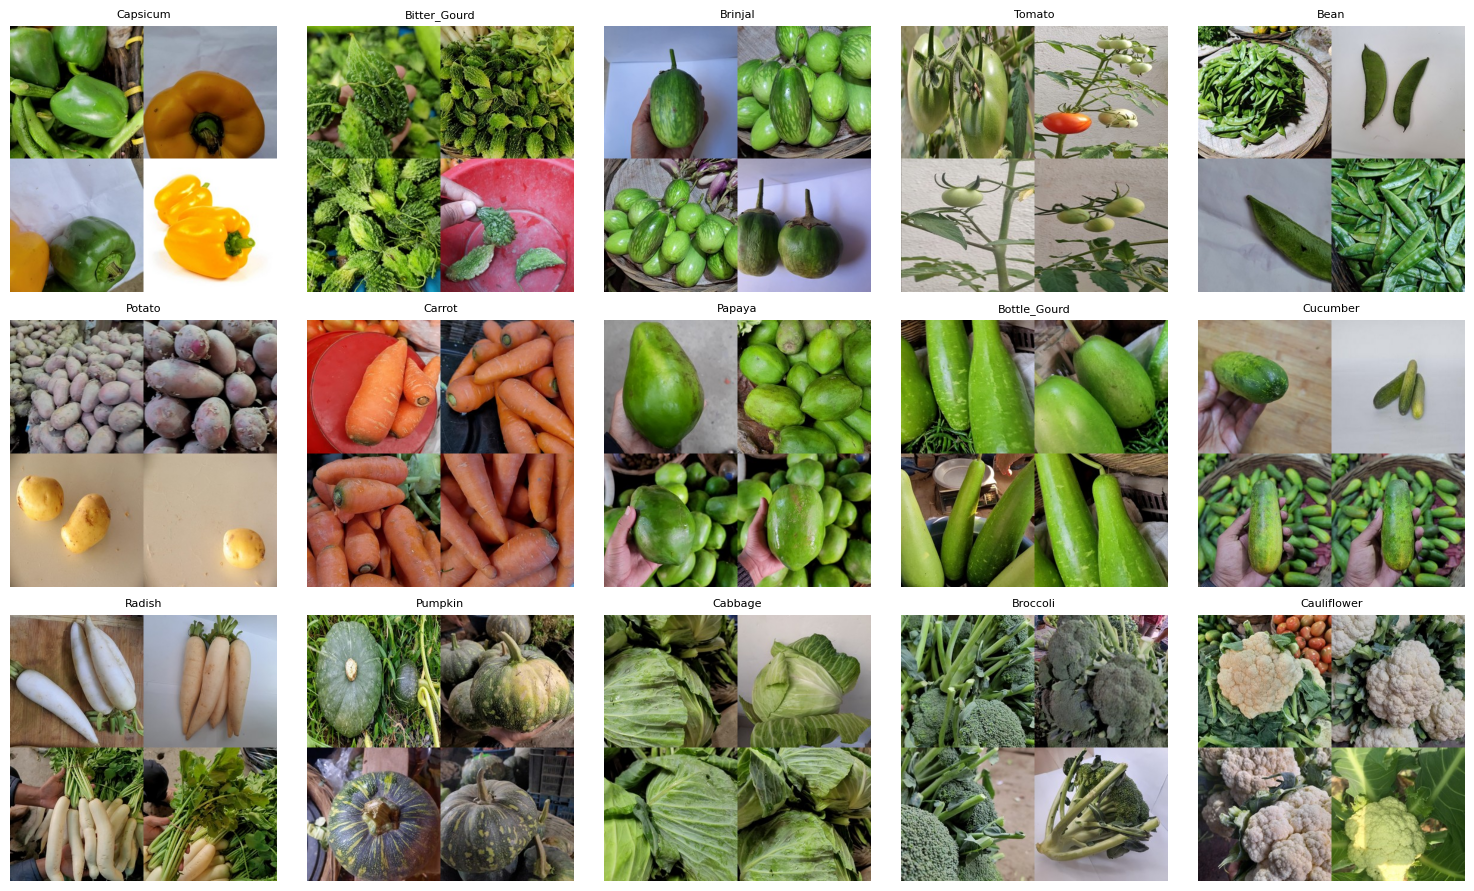

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import numpy as np

def Imagenes_ejemplo(directory, num_per_class=4, images_per_row=5):
    class_names = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
    total_classes = len(class_names)
    n_rows = int(np.ceil(total_classes / images_per_row))

    plt.figure(figsize=(images_per_row * 3, n_rows * 3))

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)
        images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        samples = random.sample(images, min(num_per_class, len(images)))

        imgs = [mpimg.imread(os.path.join(class_path, img)) for img in samples]

        min_shape = np.min([img.shape for img in imgs], axis=0)
        imgs_resized = [img[:min_shape[0], :min_shape[1]] for img in imgs]

        top = np.hstack(imgs_resized[:2])
        bottom = np.hstack(imgs_resized[2:])
        mosaic = np.vstack([top, bottom])
        plt.subplot(n_rows, images_per_row, idx+1)
        plt.imshow(mosaic)
        plt.title(class_name, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Imagenes_ejemplo(TRAIN_DIR, num_per_class=4, images_per_row=5)




**Comentario:** Una primer aspecto que podemos apreciar del dataset es que podemos diferenciar de manera muy clara como diferenciar entre diferentes tipos de verduras, podemos ver claramente patrones como:

- Si veo muchos pixeles en naranja es una zanahoria.
- Si veo una textura de muchos puntitos verdes es un brocoli
- Si veo una textura de muchos puntos y rugosa blanca es una coliflor

Esto hará que la red neuronal aprenda muy rápido a ditinguir entre clases y de manera muy acertada.


In [ ]:
from PIL import Image
import os
from collections import Counter

def check_image_sizes(directory):
    sizes = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    sizes.append(img.size)
                except:
                  print("No se puede abrir la imagen")
    size_counts = Counter(sizes)

    print("--- Tamaños de imagenes ---")
    for size, count in size_counts.items():
        print(f"{size}: {count} imagenes")

    print(f"\nTotal de imagenes: {sum(size_counts.values())}")


check_image_sizes(TRAIN_DIR)


--- Tamaños de imagenes ---
(224, 224): 14994 imagenes
(224, 200): 1 imagenes
(224, 205): 1 imagenes
(224, 193): 1 imagenes
(224, 198): 1 imagenes
(224, 210): 1 imagenes
(224, 211): 1 imagenes

Total de imagenes: 15000


**Comentario:** Viendo que solo hay 6 imagenes de un total de 15.000 con un tamaño distinto, las eliminamos del conjunto de train para evitar distorsiones.


In [ ]:
import shutil

TRAIN_DIR = BASE_FOLDER + "/Vegetable Images/train"
DISCARD_DIR = BASE_FOLDER + "/Vegetable Images/train_descartadas"
os.makedirs(DISCARD_DIR, exist_ok=True)

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        discard_class_path = os.path.join(DISCARD_DIR, class_name)
        os.makedirs(discard_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                if img.size != (224, 224):
                    shutil.move(img_path, os.path.join(discard_class_path, img_name))
            except:
                print(f"No se puede abrir la imagen: {img_path}")


In [ ]:
# Volvemos a comprovar si hemos hecho el descarte correctamente

check_image_sizes(TRAIN_DIR)

--- Tamaños de imagenes ---
(224, 224): 14994 imagenes

Total de imagenes: 14994


### Decisión sobre preprocesamiento de imágenes

**Comentario sobre la normalización de tamaños:**

La decisión de eliminar las 6 imágenes con tamaños diferentes (diferentes a 224x224) se justifica por:

1. **Consistencia en el procesamiento:** Todas las imágenes deben tener el mismo tamaño para poder ser procesadas en lotes (batches) por la red neuronal
2. **Impacto mínimo:** Eliminar 6 imágenes de un total de 15.000 (0.04%) no afecta significativamente la representatividad del dataset
3. **Evitar distorsiones:** Redimensionar imágenes con aspect ratios muy diferentes puede distorsionar los patrones visuales que la red debe aprender
4. **Optimización computacional:** Trabajar con tamaños uniformes permite un procesamiento más eficiente en GPU

### Declaración de variables comunes

Declaramos un primer bloque de variables que iremos necesitando a lo largo del programa, como el nombre y número de clases posibles, la longitud del dataset, el tamaño de imagen o el Batch size

In [ ]:
# DATASET VARIABLES
DATASET_LEN=14994
CLASS_NAMES = os.listdir(TRAIN_DIR)
NUM_CLASSES=len(CLASS_NAMES)
IMG_SIZE=(224,224)
BATCH_SIZE=64

# 3. ACONDICIONAMIENTO DE CONJUNTO DE DATOS


Para el acondicionamiento de datos se ha utilizado la clase ImageDataGenerator, y se ha tomado la decisión de no aplicar data augmentation, dado que en una primera iteración el modelo ha arrojado unos resultados muy buenos y no se ha visto necesario, ya la propia naturaleza del dataset origen es muy rica y variada.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255) # Normalizamos la imagenes

validation_datagen = ImageDataGenerator(rescale=1./255)

# Solo para validación final, no para entrenamiento
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    shuffle=True,
    batch_size=BATCH_SIZE
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14994 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


### Justificación de la estrategia de Data Augmentation

En este proyecto se ha tomado la decisión de no aplicar técnicas de Data Augmentation (rotaciones, flips, zooms, etc.) por las siguientes razones:

1. **Dataset suficientemente grande:** Con ~15.000 imágenes de entrenamiento, el modelo tiene suficientes ejemplos para aprender
2. **Alta variabilidad natural:** Las imágenes del dataset ya presentan gran variabilidad en términos de iluminación, fondo, orientación y escala
3. **Resultados satisfactorios iniciales:** Los experimentos preliminares mostraron que el modelo alcanza alta precisión sin necesidad de augmentation
4. **Tiempo de entrenamiento:** Evitar augmentation reduce significativamente el tiempo de procesamiento

**Nota:** Si en iteraciones futuras se observara overfitting o se deseara mejorar la robustez del modelo, se podría reconsiderar la aplicación de técnicas como rotaciones pequeñas (±15°), flips horizontales, o ajustes de brillo/contraste.

# 4. Desarrollo de la arquitectura de red neuronal y entrenamiento de la solución

Nuevamente definimos de manera centralizada variables que definirán como debe comportarse el entrenamiento.

In [ ]:
# TRAINING VARIABLES
NUM_EPOCHS=50
BATCH_SIZE=64
L2_REG_RATIO=1e-5
LEARNING_RATE=1e-3
KERNEL_SIZE=(3,3)
TYPE_OF_PADDING='valid'
HIDDEN_LAYERS_ACTIVATION='relu'
OUTPUT_LAYER_ACTIVATION='softmax'
LOSS_FUNCTION='categorical_crossentropy' # Para problemas multiclase con las etiquetas en one-hot-encoding se usa esta

## 4.1 Estrategia 1: Entrenar desde cero o from scratch

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

## 4.1.1 Justificación de decisiones arquitectónicas

- Dado que la naturaleza del problema es de clasificación múltiple se ha optado por elegir como función de activación de la última capa la función softmax y además de eso se ha seleccionado como función de perdida "sparse_categorical_crossentropy" dado que es la más apropiada para problemas de este tipo.

- En la última capa se han elegido tantas neuronas como en clases posibles se puede clasificar una imagen, en este caso concreto será 15 clases.

- Se han aplicado técnicas de regularización como weight regularization, dropout, batch normalization, etc.

In [ ]:
from tensorflow.keras import layers, models, regularizers
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def from_scrach_convNetClassifier():
  inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

  # BLOQUE CONVOLUCIONAL 1
  x1 = Conv2D(32, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(inputs)
  x1 = BatchNormalization()(x1)
  x1 = Conv2D(32, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x1)
  x1 = BatchNormalization()(x1)
  x1 = MaxPooling2D(pool_size=(2, 2))(x1)
  x1 = Dropout(0.25)(x1)

  # BLOQUE CONVOLUCIONAL 2
  x2 = Conv2D(64, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x1)
  x2 = BatchNormalization()(x2)
  x2 = Conv2D(64, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x2)
  x2 = BatchNormalization()(x2)
  x2 = MaxPooling2D(pool_size=(2, 2))(x2)
  x2 = Dropout(0.25)(x2)

  # BLOQUE CONVOLUCIONAL 3
  x3 = Conv2D(256, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x2)
  x3 = BatchNormalization()(x3)
  x3 = Conv2D(256, KERNEL_SIZE, padding=TYPE_OF_PADDING, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x3)
  x3 = BatchNormalization()(x3)
  x3 = MaxPooling2D(pool_size=(2, 2))(x3)
  x3 = Dropout(0.25)(x3)

  # TOP MODEL
  # Primer (y único) set de capas FC => RELU
  xfc = Flatten()(x3)
  xfc = Dense(512, activation=HIDDEN_LAYERS_ACTIVATION,
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(xfc)
  xfc = BatchNormalization()(xfc)
  xfc = Dropout(0.5)(xfc)

  # Clasificador softmax (sin regularización en la última capa)
  predictions = Dense(NUM_CLASSES, activation=OUTPUT_LAYER_ACTIVATION)(xfc)

  return Model(inputs=inputs, outputs=predictions)

convnetClassifier = from_scrach_convNetClassifier()
convnetClassifier.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 51, 51, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 51, 51, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 49, 49, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 49, 49, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    75,497,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,04

 Total params: 76,313,903 (291.11 MB)

 Trainable params: 76,311,471 (291.11 MB)

 Non-trainable params: 2,432 (9.50 KB)

### Análisis detallado de la arquitectura From Scratch

**Comentario sobre las técnicas de regularización aplicadas:**

La arquitectura diseñada incorpora múltiples técnicas de regularización en cada bloque convolucional:

1. **L2 Regularization (Weight Decay):**
   - Penaliza pesos grandes para evitar overfitting
   - Ratio de 1e-5 aplicado en todas las capas convolucionales y densas

2. **Batch Normalization:**
   - Normaliza las activaciones entre capas
   - Acelera el entrenamiento y actúa como regularizador
   - Aplicada después de cada capa convolucional

3. **Dropout:**
   - 0.25 en capas convolucionales (ligero)
   - 0.5 en capas densas (más agresivo)
   - Reduce la co-adaptación de neuronas

4. **Max Pooling:**
   - Reduce dimensionalidad espacial
   - Proporciona invariancia a pequeñas traslaciones
   - Ayuda a extraer características más robustas

**Progresión de filtros:** 32 → 64 → 256
- Aumenta gradualmente la capacidad de aprendizaje de características complejas
- Las primeras capas detectan bordes y texturas simples
- Las últimas capas aprenden patrones de alto nivel específicos de cada verdura

#### Compilado y entrenamiento

## 4.1.2 Monitorización del proceso de entrenamiento para la toma de decisiones en la red neuronal from scratch

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from datetime import datetime

print("[INFO]: Compilando el modelo...")
opt = Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    clipnorm=1.0
)

convnetClassifier.compile(loss=LOSS_FUNCTION, optimizer=opt, metrics=["accuracy"])

# Guardar el mejor modelo automáticamente
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_model_path = f"./content/models/best_model_{timestamp}.h5"
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Detener si no mejora en 5 épocas
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1, restore_best_weights=True)

print("[INFO]: Entrenando la red...")
H = convnetClassifier.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping])

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6324 - loss: 1.3449
Epoch 1: val_accuracy improved from -inf to 0.09133, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 134s 506ms/step - accuracy: 0.6330 - loss: 1.3429 - val_accuracy: 0.0913 - val_loss: 8.4067
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9337 - loss: 0.3708
Epoch 2: val_accuracy improved from 0.09133 to 0.54367, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 119s 507ms/step - accuracy: 0.9338 - loss: 0.3707 - val_accuracy: 0.5437 - val_loss: 2.3224
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9606 - loss: 0.3009
Epoch 3: val_accuracy improved from 0.54367 to 0.85933, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 106s 452ms/step - accuracy: 0.9606 - loss: 0.3009 - val_accuracy: 0.8593 - val_loss: 0.6649
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9784 - loss: 0.2744
Epoch 4: val_accuracy did not improve from 0.85933
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 409ms/step - accuracy: 0.9784 - loss: 0.2745 - val_accuracy: 0.7973 - val_loss: 1.2206
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9774 - loss: 0.2966
Epoch 5: val_accuracy improved from 0.85933 to 0.88867, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 118s 502ms/step - accuracy: 0.9774 - loss: 0.2966 - val_accuracy: 0.8887 - val_loss: 0.6211
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9822 - loss: 0.3007
Epoch 6: val_accuracy improved from 0.88867 to 0.92500, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 109s 464ms/step - accuracy: 0.9822 - loss: 0.3007 - val_accuracy: 0.9250 - val_loss: 0.5595
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9875 - loss: 0.2870
Epoch 7: val_accuracy improved from 0.92500 to 0.96267, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 108s 461ms/step - accuracy: 0.9875 - loss: 0.2871 - val_accuracy: 0.9627 - val_loss: 0.4056
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9838 - loss: 0.3143
Epoch 8: val_accuracy did not improve from 0.96267
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 411ms/step - accuracy: 0.9837 - loss: 0.3143 - val_accuracy: 0.9363 - val_loss: 0.5604
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9837 - loss: 0.3418
Epoch 9: val_accuracy improved from 0.96267 to 0.98067, saving model to ./content/models/best_model_20251120_143921.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 123s 525ms/step - accuracy: 0.9837 - loss: 0.3418 - val_accuracy: 0.9807 - val_loss: 0.3930
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9904 - loss: 0.3401
Epoch 10: val_accuracy did not improve from 0.98067
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 408ms/step - accuracy: 0.9904 - loss: 0.3402 - val_accuracy: 0.8767 - val_loss: 0.8815
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9834 - loss: 0.3825
Epoch 11: val_accuracy did not improve from 0.98067
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 409ms/step - accuracy: 0.9834 - loss: 0.3826 - val_accuracy: 0.9390 - val_loss: 0.5984
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9886 - loss: 0.3962
Epoch 12: val_accuracy did not improve from 0.98067
235/235 ━━━━━━━━━━━━━━━━━━━━ 96s 410ms/step - accuracy: 0.9885 - loss: 0.3963 - val_accuracy: 0.9477 - val_loss: 0.5322
Epoch 13/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9910 - loss: 0.3848
Epoch 1

**Comentario**: Tal y como se pronóstico al ver el analísis del dataset, vemos que la red neuronal ha aprendido bastante rápido, a parte de por tener una arquitectura de la red neuronal bien definida y otras buenas técnicas también se debe en gran medida a que en el dataset está muy bien marcado con características como el color, la textura, etc que diferencia muy bien como clasificar las imagenes.

Adicionalmente, hemos almacenado siempre el mejor entrenamiento y si en 5 epocas no se producen mejoras se guarda la mejor epoca. Para poder monitorizar los resultados y tomar decisiones acudimos a la ejecución de la siguiente celda de código

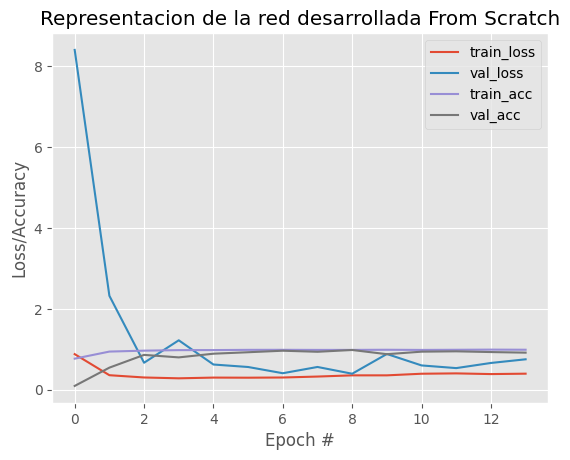

In [ ]:
import matplotlib.pyplot as plt

# Muestro gráfica de accuracy y losses
num_epochs_trained = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, num_epochs_trained), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, num_epochs_trained), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, num_epochs_trained), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, num_epochs_trained), H.history["val_accuracy"], label="val_acc")
plt.title("Representacion de la red desarrollada From Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

**Comentarios:** Aunque bien es cierto que hay una fuerte componente aleatoria y que dependiendo de la ejecución podemos apreciar diferentes comportamientos, en general entre la epoca 8-9 suele converger el modelo, las oscilaciones que vemos se deben a que la tasa de aprendizaje es lo suficientemente grande como para escapar de mínimos locales y explorar nuevos lugares.

### Almacenamiento de hiperparámetros y resultados


Se ha optado por una estrategia más nativa y rudimentaria de guardar los hiperparámetros y el nombre del modelo asociado, con el fin de poder entrenar múltiples modelos con diferentes ajustes de hiperparámetros y no perder información. Aunque bien es cierto que existen librerías de terceros que ya facilitan toda estas tareas, dado que este proyecto tiene objetivos académicos se ha optado por algo más nativo de python

In [ ]:
import json
import os
from datetime import datetime

MODELS_DIR = "./content/models"
os.makedirs(MODELS_DIR, exist_ok=True)

JSON_FILE = os.path.join(MODELS_DIR, "models.json")

# Encontrar la época con mejor val_accuracy
best_epoch = np.argmax(H.history['val_accuracy'])
print(f"\n[INFO]: Mejor época: {best_epoch + 1}/{NUM_EPOCHS}")
print(f"[INFO]: Val Accuracy: {H.history['val_accuracy'][best_epoch]:.4f}")

hyperparameters = {
    "model_filename": best_model_path.split('/')[-1],
    "best_epoch": int(best_epoch + 1),
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "l2_reg_ratio": L2_REG_RATIO,
    "kernel_size": KERNEL_SIZE,
    "type_of_padding": TYPE_OF_PADDING,
    "hidden_layers_activation": HIDDEN_LAYERS_ACTIVATION,
    "output_layer_activation": OUTPUT_LAYER_ACTIVATION,
    "loss_function": LOSS_FUNCTION,
    "results": {
        "train_loss": float(H.history['loss'][best_epoch]),
        "train_accuracy": float(H.history['accuracy'][best_epoch]),
        "val_loss": float(H.history['val_loss'][best_epoch]),
        "val_accuracy": float(H.history['val_accuracy'][best_epoch])
    }
}

best_scratch_model_path = best_model_path

if os.path.exists(JSON_FILE):
    with open(JSON_FILE, 'r') as f:
        models = json.load(f)
else:
    models = []

models.append(hyperparameters)

with open(JSON_FILE, 'w') as f:
    json.dump(models, f, indent=2)

print(f"[INFO]: Hiperparámetros guardados en: {JSON_FILE}")


[INFO]: Mejor época: 9/50
[INFO]: Val Accuracy: 0.9807
[INFO]: Hiperparámetros guardados en: ./content/models/models.json


## 4.2 Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

In [ ]:
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input

## RESNET50
def pretrained_resnet50_classifier():
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs
    )

    for layer in base_model.layers:
        layer.trainable = False


    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu",
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(NUM_CLASSES, activation=OUTPUT_LAYER_ACTIVATION)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


## MobileNetV2
def pretrained_mobilenetv2_classifier():
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu",
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation="relu",
              kernel_regularizer=regularizers.l2(L2_REG_RATIO))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(NUM_CLASSES, activation=OUTPUT_LAYER_ACTIVATION)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
#Transfer Learning RESNET
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from datetime import datetime

# Generadores sin aumentacioon, solo procesamiento ResNet50
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    shuffle=True,
    batch_size=BATCH_SIZE
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Model ResNet50 pre entrenado
model = pretrained_resnet50_classifier()

# Compilacion
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss=LOSS_FUNCTION, metrics=["accuracy"])

# Callbacks: guardar mejor modelo y early stop
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_model_path = f"./content/models/best_model_pretrain_RESNET_{timestamp}.h5"
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1, restore_best_weights=True)

# Entrenamiento
print("[INFO] Entrenando Transfer Learning ResNet50...")
history_transfer = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)



Found 14994 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Entrenando Transfer Learning ResNet50...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9279 - loss: 0.2865
Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to ./content/models/best_model_pretrain_RESNET_20251120_150644.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 94s 324ms/step - accuracy: 0.9281 - loss: 0.2857 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9979 - loss: 0.0169
Epoch 2: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 53s 224ms/step - accuracy: 0.9979 - loss: 0.0169 - val_accuracy: 0.9990 - val_loss: 0.0113
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9994 - loss: 0.0118
Epoch 3: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 53s 226ms/step - accuracy: 0.9994 - loss: 0.0118 - val_accuracy: 0.9990 - val_loss: 0.0111
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9996 - loss: 0.0109
Epoch 4: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 50s 212ms/step - accuracy: 0.9996 - loss: 0.0109 - val_accuracy: 0.9997 - val_loss: 0.0095
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9991 - loss: 0.0104
Epoch 5: val_ac

In [ ]:
#Fine tuning
UNFREEZE_LAYERS = 50

for layer in model.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# Compilar con learning rate pequeño
fine_opt = Adam(learning_rate=1e-5)

model.compile(optimizer=fine_opt, loss=LOSS_FUNCTION, metrics=["accuracy"])

print("[INFO] Entrenando Fine-Tuning...")
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

[INFO] Entrenando Fine-Tuning...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9986 - loss: 0.0138
Epoch 1: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 103s 353ms/step - accuracy: 0.9986 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0098
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 0.0100
Epoch 2: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 68s 287ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 0.9997 - val_loss: 0.0103
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9997 - loss: 0.0103
Epoch 3: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 69s 293ms/step - accuracy: 0.9997 - loss: 0.0103 - val_accuracy: 0.9997 - val_loss: 0.0097
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 1.0000 - loss: 0.0091
Epoch 4: val_accuracy did not improve from 1.00000
235/235 ━━━━━━━━━━━━━━━━━━━━ 67s 284ms/step - accu

In [ ]:
import json

MODELS_DIR = "./content/models"
os.makedirs(MODELS_DIR, exist_ok=True)
JSON_FILE = os.path.join(MODELS_DIR, "models_pretrain_RESNET.json")

best_epoch_ft = int(np.argmax(history_finetune.history["val_accuracy"]))

hyperparameters = {
    "architecture": "ResNet50",
    "best_model": best_model_path.split("/")[-1],
    "transfer_learning_epochs": len(history_transfer.history["loss"]),
    "fine_tuning_epochs": len(history_finetune.history["loss"]),
    "unfreeze_layers": UNFREEZE_LAYERS,
    "l2_reg_ratio": L2_REG_RATIO,
    "dropout": 0.5,
    "learning_rate_tl": LEARNING_RATE,
    "learning_rate_ft": 1e-5,
    "results": {
        "val_accuracy_transfer": float(max(history_transfer.history["val_accuracy"])),
        "val_accuracy_finetune": float(max(history_finetune.history["val_accuracy"]))
    }
}


if os.path.exists(JSON_FILE):
    with open(JSON_FILE, "r") as f:
        models = json.load(f)
else:
    models = []

models.append(hyperparameters)

with open(JSON_FILE, "w") as f:
    json.dump(models, f, indent=2)

print("[INFO] ResNet50 guardada")


[INFO] ResNet50 guardada


In [ ]:
#Transfer Learning MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from datetime import datetime

model = pretrained_mobilenetv2_classifier()

opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss=LOSS_FUNCTION, metrics=["accuracy"])


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_model_path = f"./content/models/best_model_pretrain_MOBILENETV2_{timestamp}.h5"
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', verbose=1, restore_best_weights=True)

print("[INFO] Entrenando Transfer Learning MobileNetV2...")
history_transfer = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)


/tmp/ipython-input-1652258862.py:36: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Entrenando Transfer Learning MobileNetV2...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.5976 - loss: 1.4672
Epoch 1: val_accuracy improved from -inf to 0.92300, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 93s 309ms/step - accuracy: 0.5982 - loss: 1.4647 - val_accuracy: 0.9230 - val_loss: 0.2625
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8947 - loss: 0.3488
Epoch 2: val_accuracy improved from 0.92300 to 0.95033, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 176ms/step - accuracy: 0.8947 - loss: 0.3487 - val_accuracy: 0.9503 - val_loss: 0.1747
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9249 - loss: 0.2459
Epoch 3: val_accuracy improved from 0.95033 to 0.96033, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.9250 - loss: 0.2458 - val_accuracy: 0.9603 - val_loss: 0.1436
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9478 - loss: 0.1848
Epoch 4: val_accuracy improved from 0.96033 to 0.96200, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


...

235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 176ms/step - accuracy: 0.9682 - loss: 0.1160 - val_accuracy: 0.9720 - val_loss: 0.1153
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9727 - loss: 0.1042
Epoch 11: val_accuracy did not improve from 0.97200
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.9727 - loss: 0.1042 - val_accuracy: 0.9647 - val_loss: 0.1338
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9749 - loss: 0.0983
Epoch 12: val_accuracy did not improve from 0.97200
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.9749 - loss: 0.0983 - val_accuracy: 0.9690 - val_loss: 0.1284
Epoch 13/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9706 - loss: 0.1060
Epoch 13: val_accuracy improved from 0.97200 to 0.97267, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9706 - loss: 0.1060 - val_accuracy: 0.9727 - val_loss: 0.1111
Epoch 14/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9774 - loss: 0.0890
Epoch 14: val_accuracy improved from 0.97267 to 0.97567, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 176ms/step - accuracy: 0.9774 - loss: 0.0890 - val_accuracy: 0.9757 - val_loss: 0.1035
Epoch 15/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9760 - loss: 0.0933
Epoch 15: val_accuracy did not improve from 0.97567
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.9760 - loss: 0.0933 - val_accuracy: 0.9757 - val_loss: 0.1083
Epoch 16/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9743 - loss: 0.0898
Epoch 16: val_accuracy improved from 0.97567 to 0.97667, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.9743 - loss: 0.0899 - val_accuracy: 0.9767 - val_loss: 0.1056
Epoch 17/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9822 - loss: 0.0728
Epoch 17: val_accuracy did not improve from 0.97667
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 174ms/step - accuracy: 0.9822 - loss: 0.0728 - val_accuracy: 0.9630 - val_loss: 0.1462
Epoch 18/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9801 - loss: 0.0820
Epoch 18: val_accuracy did not improve from 0.97667
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.9801 - loss: 0.0820 - val_accuracy: 0.9747 - val_loss: 0.1139
Epoch 19/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9793 - loss: 0.0863
Epoch 19: val_accuracy improved from 0.97667 to 0.97733, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.9793 - loss: 0.0862 - val_accuracy: 0.9773 - val_loss: 0.1072
Epoch 20/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9846 - loss: 0.0701
Epoch 20: val_accuracy did not improve from 0.97733
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.9846 - loss: 0.0701 - val_accuracy: 0.9743 - val_loss: 0.1233
Epoch 21/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9797 - loss: 0.0781
Epoch 21: val_accuracy did not improve from 0.97733
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9797 - loss: 0.0781 - val_accuracy: 0.9727 - val_loss: 0.1203
Epoch 22/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9820 - loss: 0.0748
Epoch 22: val_accuracy did not improve from 0.97733
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.9820 - loss: 0.0748 - val_accuracy: 0.9760 - val_loss: 0.1195
Epoch 23/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9827 - loss: 0.0753
Epoch 23

In [ ]:
#Fine tuning
UNFREEZE_LAYERS = 50

for layer in model.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# Compilar con learning rate pequeño
fine_opt = Adam(learning_rate=1e-5)

model.compile(optimizer=fine_opt, loss=LOSS_FUNCTION, metrics=["accuracy"])

print("[INFO] Entrenando Fine-Tuning...")
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

[INFO] Entrenando Fine-Tuning...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9801 - loss: 0.0779
Epoch 1: val_accuracy improved from 0.97733 to 0.97800, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 252ms/step - accuracy: 0.9801 - loss: 0.0779 - val_accuracy: 0.9780 - val_loss: 0.1025
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9852 - loss: 0.0634
Epoch 2: val_accuracy improved from 0.97800 to 0.97867, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 183ms/step - accuracy: 0.9852 - loss: 0.0634 - val_accuracy: 0.9787 - val_loss: 0.0971
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9897 - loss: 0.0542
Epoch 3: val_accuracy improved from 0.97867 to 0.98000, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9897 - loss: 0.0542 - val_accuracy: 0.9800 - val_loss: 0.0972
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9900 - loss: 0.0474
Epoch 4: val_accuracy improved from 0.98000 to 0.98433, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9900 - loss: 0.0474 - val_accuracy: 0.9843 - val_loss: 0.0839
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9913 - loss: 0.0468
Epoch 5: val_accuracy did not improve from 0.98433
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9913 - loss: 0.0468 - val_accuracy: 0.9843 - val_loss: 0.0786
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9927 - loss: 0.0413
Epoch 6: val_accuracy improved from 0.98433 to 0.98600, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.9927 - loss: 0.0413 - val_accuracy: 0.9860 - val_loss: 0.0701
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9951 - loss: 0.0379
Epoch 7: val_accuracy did not improve from 0.98600
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9951 - loss: 0.0379 - val_accuracy: 0.9860 - val_loss: 0.0734
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9944 - loss: 0.0359
Epoch 8: val_accuracy did not improve from 0.98600
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9944 - loss: 0.0360 - val_accuracy: 0.9830 - val_loss: 0.0741
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9944 - loss: 0.0385
Epoch 9: val_accuracy improved from 0.98600 to 0.98833, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - accuracy: 0.9944 - loss: 0.0385 - val_accuracy: 0.9883 - val_loss: 0.0648
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9959 - loss: 0.0366
Epoch 10: val_accuracy did not improve from 0.98833
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9959 - loss: 0.0366 - val_accuracy: 0.9857 - val_loss: 0.0733
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9957 - loss: 0.0315
Epoch 11: val_accuracy did not improve from 0.98833
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.9957 - loss: 0.0315 - val_accuracy: 0.9870 - val_loss: 0.0658
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9968 - loss: 0.0305
Epoch 12: val_accuracy did not improve from 0.98833
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.9968 - loss: 0.0305 - val_accuracy: 0.9880 - val_loss: 0.0720
Epoch 13/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9961 - loss: 0.0305
Epoch 13

235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9961 - loss: 0.0305 - val_accuracy: 0.9887 - val_loss: 0.0606
Epoch 14/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9964 - loss: 0.0310
Epoch 14: val_accuracy did not improve from 0.98867
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.9964 - loss: 0.0310 - val_accuracy: 0.9783 - val_loss: 0.0873
Epoch 15/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9973 - loss: 0.0297
Epoch 15: val_accuracy did not improve from 0.98867
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.9973 - loss: 0.0297 - val_accuracy: 0.9857 - val_loss: 0.0748
Epoch 16/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9972 - loss: 0.0279
Epoch 16: val_accuracy improved from 0.98867 to 0.99033, saving model to ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.9972 - loss: 0.0279 - val_accuracy: 0.9903 - val_loss: 0.0559
Epoch 17/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9974 - loss: 0.0269
Epoch 17: val_accuracy did not improve from 0.99033
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.9974 - loss: 0.0269 - val_accuracy: 0.9890 - val_loss: 0.0623
Epoch 18/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9972 - loss: 0.0285
Epoch 18: val_accuracy did not improve from 0.99033
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.9972 - loss: 0.0285 - val_accuracy: 0.9893 - val_loss: 0.0618
Epoch 19/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9986 - loss: 0.0257
Epoch 19: val_accuracy did not improve from 0.99033
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - accuracy: 0.9986 - loss: 0.0257 - val_accuracy: 0.9867 - val_loss: 0.0614
Epoch 20/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9972 - loss: 0.0285
Epoch 20

In [ ]:
import json

MODELS_DIR = "./content/models"
os.makedirs(MODELS_DIR, exist_ok=True)
JSON_FILE = os.path.join(MODELS_DIR, "models_pretrain_MobileNetV2.json")

best_epoch_ft = int(np.argmax(history_finetune.history["val_accuracy"]))

hyperparameters = {
    "architecture": "ResNet50",
    "best_model": best_model_path.split("/")[-1],
    "transfer_learning_epochs": len(history_transfer.history["loss"]),
    "fine_tuning_epochs": len(history_finetune.history["loss"]),
    "unfreeze_layers": UNFREEZE_LAYERS,
    "l2_reg_ratio": L2_REG_RATIO,
    "dropout": 0.5,
    "learning_rate_tl": LEARNING_RATE,
    "learning_rate_ft": 1e-5,
    "results": {
        "val_accuracy_transfer": float(max(history_transfer.history["val_accuracy"])),
        "val_accuracy_finetune": float(max(history_finetune.history["val_accuracy"]))
    }
}


if os.path.exists(JSON_FILE):
    with open(JSON_FILE, "r") as f:
        models = json.load(f)
else:
    models = []

models.append(hyperparameters)

with open(JSON_FILE, "w") as f:
    json.dump(models, f, indent=2)

print("[INFO] MobileNetV2 guardada")

[INFO] MobileNetV2 guardada


# 6. Evaluación del modelo predictivo y planteamiento de la siguiente prueba experimental

## Evaluación del modelo from Scratch

A continuación se evalúa el modelo entrenado desde cero en el conjunto de datos de prueba para medir su rendimiento final.

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

print(f"[INFO]: Cargando modelo desde {best_scratch_model_path}")
best_model = load_model(best_scratch_model_path)

print("[INFO]: Evaluando red neuronal con conjunto de test...")


predictions = best_model.predict(test_generator, verbose=1)


y_true = test_generator.classes
y_pred = predictions.argmax(axis=1)
class_names = list(test_generator.class_indices.keys())

print("\n" + "="*60)
print("CLASSIFICATION REPORT - Conjunto de Test")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

[INFO]: Cargando modelo desde /content/content/models/best_model_20251120_143921.h5


[INFO]: Evaluando red neuronal con conjunto de test...
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step

CLASSIFICATION REPORT - Conjunto de Test
              precision    recall  f1-score   support

        Bean       0.97      0.99      0.98       200
Bitter_Gourd       1.00      0.98      0.99       200
Bottle_Gourd       0.99      0.99      0.99       200
     Brinjal       0.94      0.98      0.96       200
    Broccoli       0.95      0.96      0.96       200
     Cabbage       0.99      0.94      0.97       200
    Capsicum       1.00      0.96      0.98       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.97      0.96      0.96       200
    Cucumber       1.00      0.95      0.97       200
      Papaya       0.97      0.98      0.98       200
      Potato       0.99      1.00      1.00       200
     Pumpkin       0.96      1.00      0.98       200
      Radish       1.00      1.00      1.00       200
      Tomato       0.98      0.96      0.97       2

## Evaluación del modelo RESNET

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Buscar el mejor modelo guardado de que comienza con best_model_pretrain_RESNET en la carpeta content/models
best_model_path = None
for filename in os.listdir(MODELS_DIR):
    if filename.startswith("best_model_pretrain_RESNET"):
        best_model_path = os.path.join(MODELS_DIR, filename)
        break



print(f"[INFO]: Cargando modelo desde {best_model_path}")
best_model = load_model(best_model_path)

# RE-DEFINIR test_datagen y test_generator CON EL PREPROCESSING CORRECTO PARA RESNET50
test_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator_resnet = test_datagen_resnet.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Evaluando el modelo con el conjunto de test
print("[INFO]: Evaluando red neuronal con conjunto de test...")

# Obtener predicciones
predictions = best_model.predict(test_generator_resnet, verbose=1)

# Obtener las etiquetas reales del generador
y_true = test_generator_resnet.classes

# Obtener las clases predichas
y_pred = predictions.argmax(axis=1)

# Obtener los nombres de las clases
class_names = list(test_generator_resnet.class_indices.keys())

# Generar el classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - Conjunto de Test")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

[INFO]: Cargando modelo desde ./content/models/best_model_pretrain_RESNET_20251120_150644.h5


Found 3000 images belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


[INFO]: Evaluando red neuronal con conjunto de test...
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 290ms/step

CLASSIFICATION REPORT - Conjunto de Test
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       0.99      1.00      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      0.99      0.99       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      0.99      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       

## Evaluación del modelo MobileNET

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Buscar el mejor modelo guardado de que comienza con best_model_pretrain_RESNET en la carpeta content/models
best_model_path = None
for filename in os.listdir(MODELS_DIR):
    if filename.startswith("best_model_pretrain_MOBILENETV2"):
        best_model_path = os.path.join(MODELS_DIR, filename)
        break

print(f"[INFO]: Cargando modelo desde {best_model_path}")
best_model = load_model(best_model_path)

# RE-DEFINIR test_datagen y test_generator CON EL PREPROCESSING CORRECTO PARA RESNET50
test_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator_resnet = test_datagen_resnet.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Evaluando el modelo con el conjunto de test
print("[INFO]: Evaluando red neuronal con conjunto de test...")

# Obtener predicciones
predictions = best_model.predict(test_generator_resnet, verbose=1)

# Obtener las etiquetas reales del generador
y_true = test_generator_resnet.classes

# Obtener las clases predichas
y_pred = predictions.argmax(axis=1)

# Obtener los nombres de las clases
class_names = list(test_generator_resnet.class_indices.keys())

# Generar el classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - Conjunto de Test")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

[INFO]: Cargando modelo desde ./content/models/best_model_pretrain_MOBILENETV2_20251120_151956.h5


Found 3000 images belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


[INFO]: Evaluando red neuronal con conjunto de test...
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 259ms/step

CLASSIFICATION REPORT - Conjunto de Test
              precision    recall  f1-score   support

        Bean       0.99      0.99      0.99       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       0.99      1.00      0.99       200
     Brinjal       0.98      0.98      0.98       200
    Broccoli       0.99      0.99      0.99       200
     Cabbage       0.99      1.00      1.00       200
    Capsicum       0.99      0.99      0.99       200
      Carrot       1.00      0.99      0.99       200
 Cauliflower       0.99      0.98      0.99       200
    Cucumber       0.99      0.99      0.99       200
      Papaya       0.99      0.99      0.99       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.98      0.98      0.98       200
      Radish       0.99      0.99      0.99       200
      Tomato       1.00      0.99      0.99       

### Comparacion de resultados de los modelos


In [ ]:
import json

scratch_file = "./content/models/models.json"
pretrain_Resnet_file = "./content/models/models_pretrain_RESNET.json"
pretrain_MobileNetV2_file = "./content/models/models_pretrain_MobileNetV2.json"

# Carregar fitxers
with open(scratch_file, "r") as f:
    scratch_models = json.load(f)

with open(pretrain_Resnet_file, "r") as f:
    pretrain_resnet_models = json.load(f)

with open(pretrain_MobileNetV2_file, "r") as f:
    pretrain_mobilenet_models = json.load(f)

print("\n===  Comparación de modelos ===\n")

def print_model_info(title, info):
    print(f"--- {title} ---")
    for k, v in info.items():
        print(f"{k}: {v}")
    print()

# Obtener mejor modelo de cada categoria
best_scratch = max(scratch_models, key=lambda x: x["results"]["val_accuracy"])
best_resnet = max(pretrain_resnet_models, key=lambda x: x["results"]["val_accuracy_finetune"])
best_mobilenet = max(pretrain_mobilenet_models, key=lambda x: x["results"]["val_accuracy_finetune"])

# Mostrar información
print_model_info("Mejor modelo From Scratch", {
    "fichero": best_scratch["model_filename"],
    "val_accuracy": best_scratch["results"]["val_accuracy"],
    "best_epoch": best_scratch["best_epoch"],
    "hyperparams": {
        "kernel_size": best_scratch["kernel_size"],
        "l2": best_scratch["l2_reg_ratio"],
        "batch_size": best_scratch["batch_size"]
    }
})

print_model_info("Mejor modelo Pretrained ResNet50", {
    "arquitectura": best_resnet["architecture"],
    "val_acc_transfer": best_resnet["results"]["val_accuracy_transfer"],
    "val_acc_finetune": best_resnet["results"]["val_accuracy_finetune"],
    "epochs_TL": best_resnet["transfer_learning_epochs"],
    "epochs_FT": best_resnet["fine_tuning_epochs"],
    "unfreeze_layers": best_resnet["unfreeze_layers"]
})

print_model_info("Mejor modelo Pretrained MobileNetV2", {
    "arquitectura": best_mobilenet["architecture"],
    "val_acc_transfer": best_mobilenet["results"]["val_accuracy_transfer"],
    "val_acc_finetune": best_mobilenet["results"]["val_accuracy_finetune"],
    "epochs_TL": best_mobilenet["transfer_learning_epochs"],
    "epochs_FT": best_mobilenet["fine_tuning_epochs"],
    "unfreeze_layers": best_mobilenet["unfreeze_layers"]
})

# n final
best_overall = max([
    ("From Scratch", best_scratch["results"]["val_accuracy"]),
    ("ResNet50 Pretrained", best_resnet["results"]["val_accuracy_finetune"]),
    ("MobileNetV2 Pretrained", best_mobilenet["results"]["val_accuracy_finetune"])
], key=lambda x: x[1])

print("=== RESULTADO FINAL ===")
print(f" La red mejor es: {best_overall[0]} con val_accuracy = {best_overall[1]:.4f}")


===  Comparación de modelos ===

--- Mejor modelo From Scratch ---
fichero: best_model_20251120_143921.h5
val_accuracy: 0.9806666374206543
best_epoch: 9
hyperparams: {'kernel_size': [3, 3], 'l2': 1e-05, 'batch_size': 64}

--- Mejor modelo Pretrained ResNet50 ---
arquitectura: ResNet50
val_acc_transfer: 1.0
val_acc_finetune: 1.0
epochs_TL: 6
epochs_FT: 6
unfreeze_layers: 50

--- Mejor modelo Pretrained MobileNetV2 ---
arquitectura: ResNet50
val_acc_transfer: 0.9773333072662354
val_acc_finetune: 0.9903333187103271
epochs_TL: 24
epochs_FT: 21
unfreeze_layers: 50

=== RESULTADO FINAL ===
 La red mejor es: ResNet50 Pretrained con val_accuracy = 1.0000



# Conclusiones finales

En este proyecto comparamos tres enfoques: una CNN diseñada desde cero y dos variantes con Transfer Learning (ResNet50 y MobileNetV2), ambas con fine‑tuning. ResNet50 con fine‑tuning ofrece la mejor precisión general; MobileNetV2 queda muy cerca, con la ventaja de ser más ligera y rápida. El modelo desde cero rinde bien pero, en general, se queda por debajo de los pre‑entrenados. El dataset, balanceado y con rasgos visuales muy claros, facilita el aprendizaje; el uso de Transfer Learning acelera la convergencia y mejora la capacidad de generalización.

Como siguientes pasos, proponemos una data augmentation ligera, la elaboración de una matriz de confusión y una revisión de errores, además de afinar la tasa de aprendizaje y el número de capas descongeladas. Recomendación práctica: si se prioriza la máxima precisión, usar ResNet50 con fine‑tuning; si importan tamaño y latencia, MobileNetV2 es la mejor opción. Entrenar desde cero es útil cuando se dispone de muchos datos específicos del dominio o se necesita control total sobre la arquitectura.